In [2]:
import os
import numpy as np


def read_csv_dataset(file_path: str) -> tuple[np.ndarray, np.ndarray]:
    """Load a labeled dataset from a CSV file.

    Each row is expected to have the label in the first column,
    followed by feature values in the remaining columns.

    Args:
        file_path: Path to the CSV file containing the dataset.

    Returns:
        A tuple of (features, labels) where:
            - features: np.ndarray of shape (N, D) with dtype float32
            - labels: np.ndarray of shape (N,) with dtype float32
    """
    records = [] #place holder for data

    with open(file_path, "r") as csv_file:
        for row in csv_file:
            #remove trailing newline, split by comma, convert to float32 array
            values = np.array(row.strip().split(","), dtype=np.float32) #.strp will remove \n at the end of a line ex) “5,0,0,12,…,0\n” → “5,0,0,12,…,0”
            records.append(values)

    # stack all rows into a single 2D array of shape (N, 1+D)
    # where column 0 is the label and columns 1: are the features
    dataset = np.asarray(records)
    print(dataset)

    features = dataset[:, 1:]  #pixel values
    labels   = dataset[:, 0]   #digit class (0–9)

    return features, labels


# Load training and test splits from their respective CSV files
BASE_DIR = os.path.dirname(os.getcwd()) #get the path of project
train_path = os.path.join(BASE_DIR, "data/dataset", "mnist_train.csv") # add data/dataset and mnist_train.csv to the path
test_path  = os.path.join(BASE_DIR, "data/dataset", "mnist_test.csv")

X_train, Y_train = read_csv_dataset(train_path)
X_test,  Y_test  = read_csv_dataset(test_path)


[[5. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [4. 0. 0. ... 0. 0. 0.]
 ...
 [5. 0. 0. ... 0. 0. 0.]
 [6. 0. 0. ... 0. 0. 0.]
 [8. 0. 0. ... 0. 0. 0.]]
[[7. 0. 0. ... 0. 0. 0.]
 [2. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [4. 0. 0. ... 0. 0. 0.]
 [5. 0. 0. ... 0. 0. 0.]
 [6. 0. 0. ... 0. 0. 0.]]


In [11]:
print(f"The shape of the training set: {X_train.shape}")
print(f"The shape of the test set: {X_test.shape}")
print(f"The shape of the label training set: {Y_train.shape}")
print(f"The shape of the label test set: {Y_test.shape}")

The shape of the training set: (60000, 784)
The shape of the test set: (10000, 784)
The shape of the label training set: (60000,)
The shape of the label test set: (10000,)


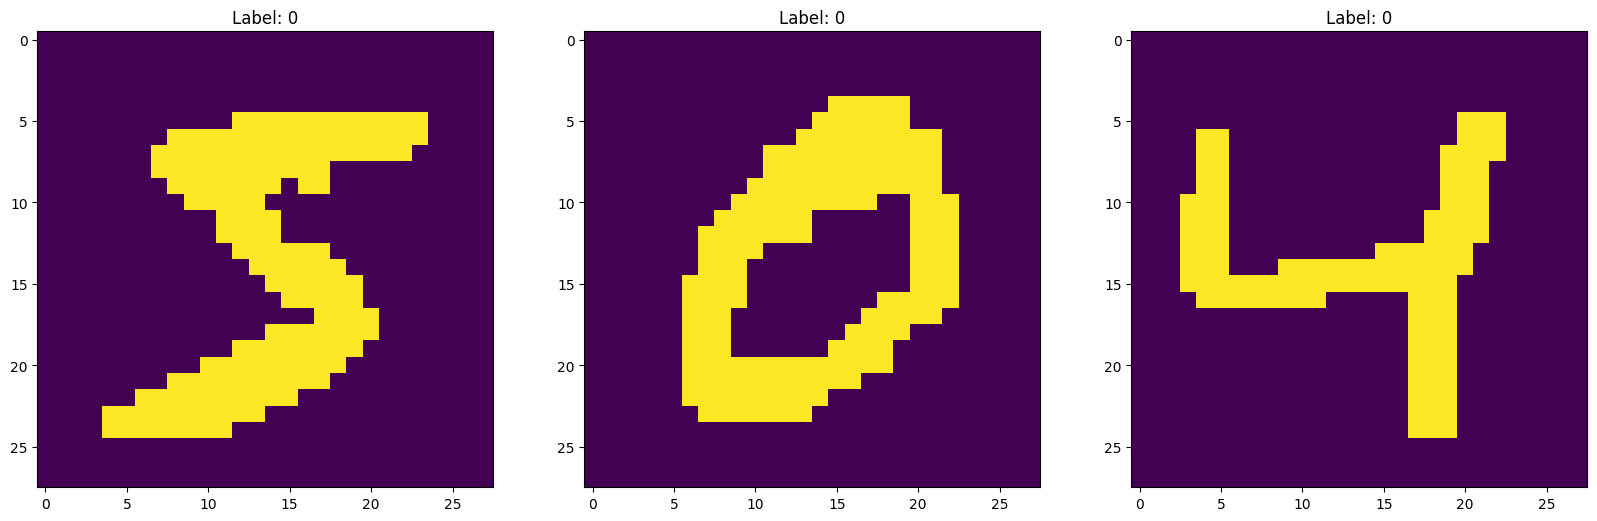

In [13]:
import matplotlib.pyplot as plt

num_images = 3
fig, axes = plt.subplots(1, num_images, figsize=(20, 10))
for i in range(num_images):
    axes[i].imshow(X_train[i].reshape(28, 28), vmin=0, vmax=1.0)
    axes[i].set_title(f"Label: {np.argmax(Y_train[i])}")
plt.show()

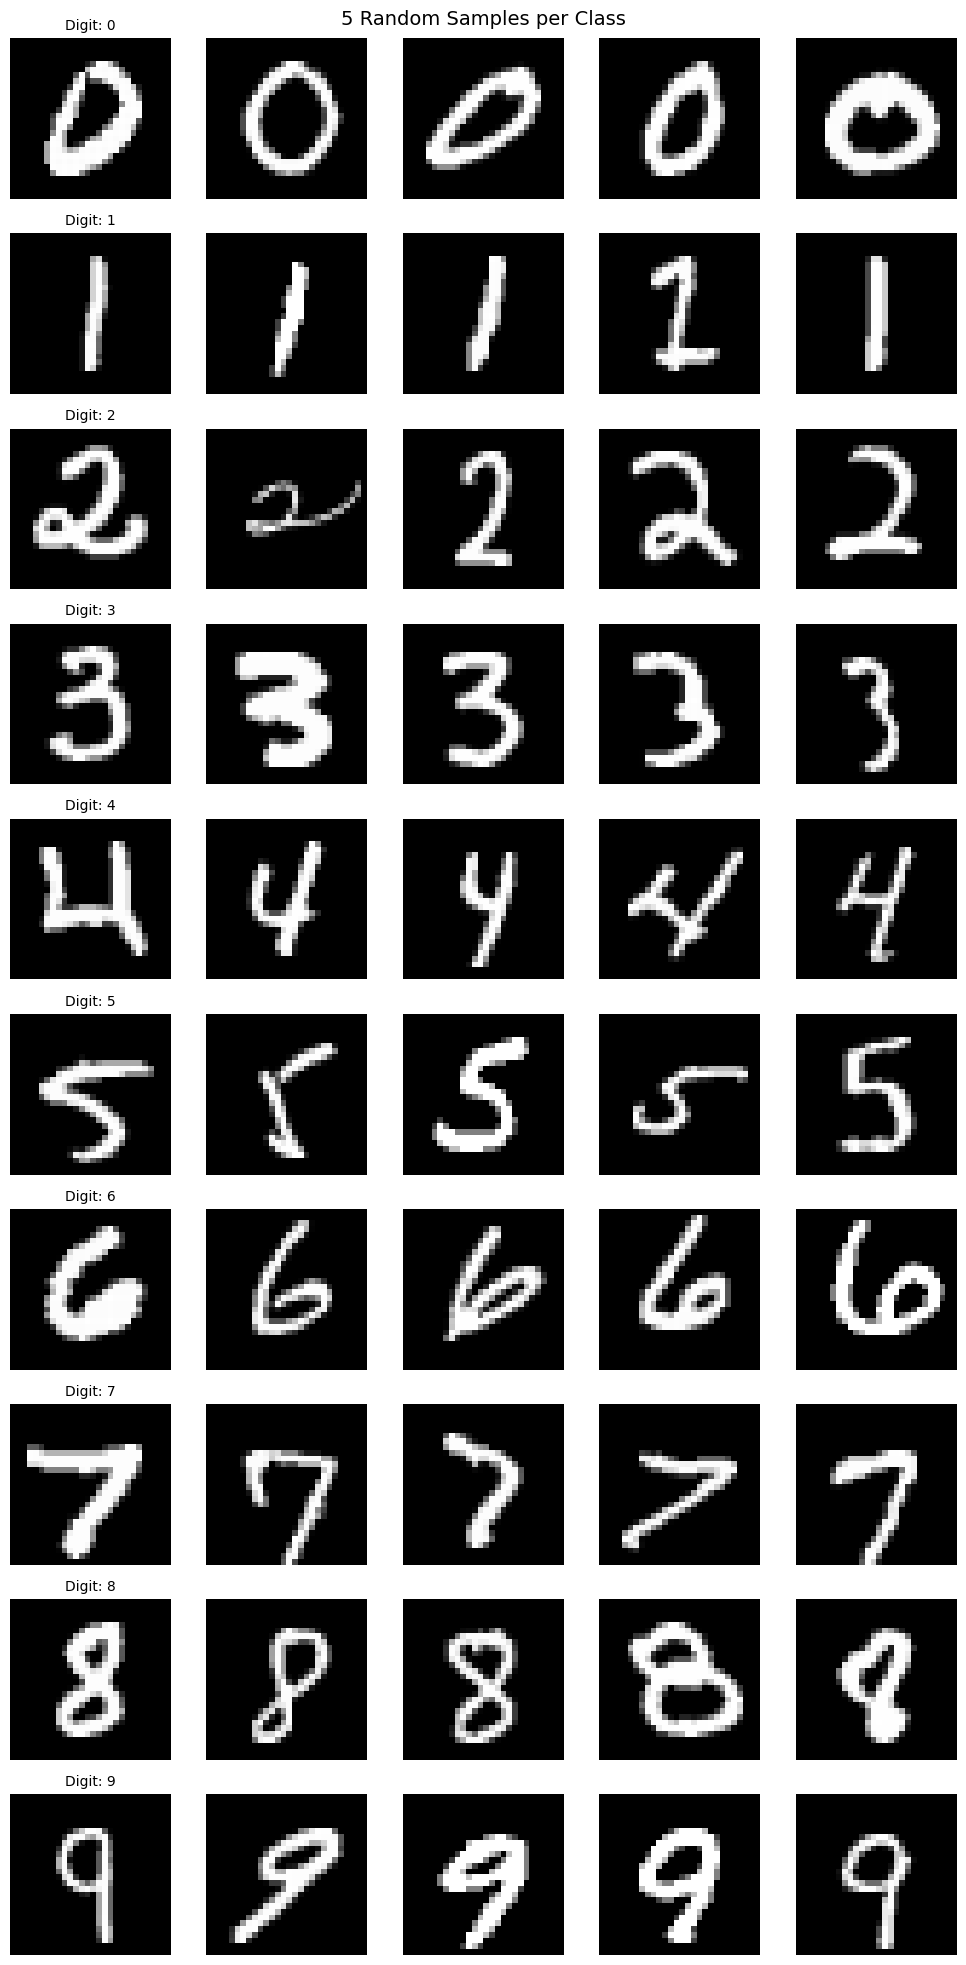

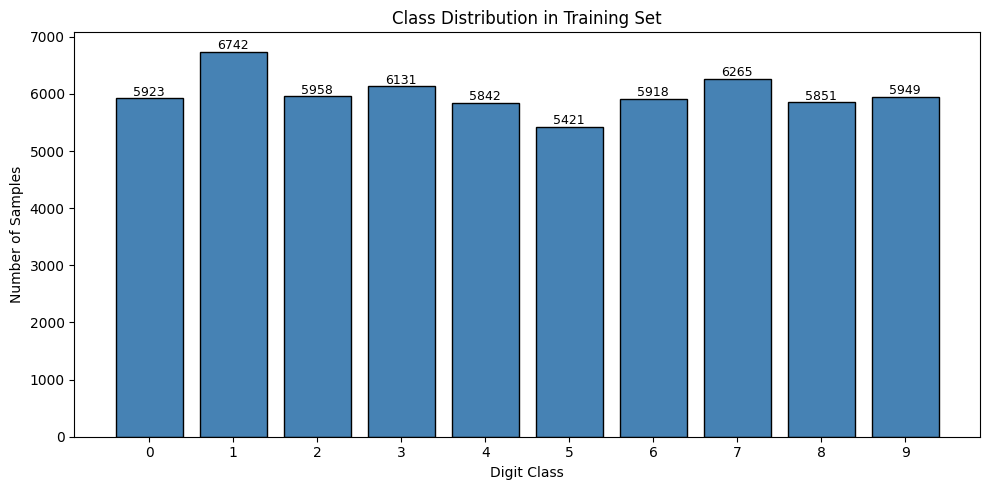

Max samples : 6742 (digit 1.0)
Min samples : 5421 (digit 5.0)
Imbalance ratio: 1.24x


In [14]:
import numpy as np
import matplotlib.pyplot as plt

#* part 2.2 and 2.2
def plot_random_samples(
    X: np.ndarray,
    Y: np.ndarray,
    samples_per_class: int = 5,
    num_classes: int = 10,
    image_shape: tuple[int, int] = (28, 28),
) -> None:
    """Display random samples from each class in a grid layout.

    Creates a grid of (num_classes x samples_per_class) where each row
    belongs to one digit class and each column is a random sample.

    Args:
        X: Feature matrix of shape (N, D) containing flattened images.
        Y: Label array of shape (N,) containing digit classes (0-9).
        samples_per_class: Number of random samples to show per class.
        num_classes: Total number of digit classes.
        image_shape: The (height, width) to reshape each sample into.
    """
    _ , axes = plt.subplots(num_classes, samples_per_class, figsize=(10, 20))

    for digit in range(num_classes):

        # get all the indexes where the label equals this digit
        class_indices = np.where(Y == digit)[0]

        # pick 5 random ones
        random_indices = np.random.choice(class_indices, size=samples_per_class, replace=False)

        for col, idx in enumerate(random_indices):
            ax = axes[digit, col]

            # each image is stored as a flat array, need to reshape it to 28x28
            image = X[idx].reshape(image_shape)

            ax.imshow(image, cmap="gray")
            ax.axis("off")

            if col == 0:
                ax.set_title(f"Digit: {digit}", fontsize=10)

    plt.suptitle("5 Random Samples per Class", fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_class_distribution(Y: np.ndarray, num_classes: int = 10) -> None:
    
    """Plot a histogram of class distribution and report imbalance.

    Visualizes how many samples exist per digit class and prints
    a simple imbalance ratio to detect dataset bias.

    Args:
        Y: Label array of shape (N,) containing digit classes (0-9).
        num_classes: Total number of digit classes.
    """
    _, ax = plt.subplots(figsize=(10, 5))

    # count how many samples we have for each digit
    unique, counts = np.unique(Y, return_counts=True)

    ax.bar(unique, counts, color="steelblue", edgecolor="black")
    ax.set_xticks(range(num_classes))
    ax.set_xlabel("Digit Class")
    ax.set_ylabel("Number of Samples")
    ax.set_title("Class Distribution in Training Set")

    # show the exact number on top of each bar
    for x, count in zip(unique, counts):
        ax.text(x, count + 50, str(count), ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    # check if the dataset is balanced or not
    most_common  = unique[counts.argmax()]
    least_common = unique[counts.argmin()]

    print(f"Max samples : {counts.max()} (digit {most_common})")
    print(f"Min samples : {counts.min()} (digit {least_common})")
    print(f"Imbalance ratio: {counts.max() / counts.min():.2f}x")


plot_random_samples(X_train, Y_train)
plot_class_distribution(Y_train)


In [17]:
import random


def split_validation(
    features: list, labels: list, val_ratio: float = 0.1
) -> tuple[list, list, list, list]:
    """Splits dataset into train and validation sets in a stratified way.

    Args:
        features: List of input samples (pixel values).
        labels: List of class labels corresponding to each sample.
        val_ratio: Fraction of data to use for validation. Defaults to 0.1.

    Returns:
        A tuple of (train_features, val_features, train_labels, val_labels).
    """

    # find all unique classes (0 to 9)
    classes = list(set(labels))
    
    val_features = []
    val_labels = []
    train_features = []
    train_labels = []

    # for each class, take 10% for validation
    for cls in classes:
        # get all indexes that belong to this class
        cls_indexes = [i for i in range(len(labels)) if labels[i] == cls]

        # shuffle the indexes randomly
        random.shuffle(cls_indexes)

        # calculate how many samples go to validation
        val_count = int(len(cls_indexes) * val_ratio)

        # split indexes into val and train
        val_idx = cls_indexes[:val_count]
        train_idx = cls_indexes[val_count:]

        # add samples to validation list
        for i in val_idx:
            val_features.append(features[i])
            val_labels.append(labels[i])
            
        # convert to Numpy array
        val_labels_numpy = np.asanyarray(val_labels)    
        val_features_numpy = np.asanyarray(val_features)

        # add samples to train list
        for i in train_idx:
            train_features.append(features[i])
            train_labels.append(labels[i])

        # convert to Numpy array
        train_labels_numpy = np.asanyarray(train_labels)
        train_features_numpy = np.asanyarray(train_features)

    return train_features_numpy, val_features_numpy, train_labels_numpy, val_labels_numpy


# run the split
X_train_final, X_val, Y_train_final, Y_val = split_validation(X_train, Y_train)

print(f"Train size:      {len(X_train_final)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size:       {len(X_test)}")


Train size:      54004
Validation size: 5996
Test size:       10000
